# Accredian Project

**Project Name:** Instructor Effectiveness Prediction
**Made by:** Harmandeep Singh

---

## Project Summary
This project analyzes instructor effectiveness using learner outcome,
engagement and feedback data. I defined effectiveness using a
weighted score, converted it to tiers (Low/Medium/High) and built
a Random Forest classifier to predict instructor tiers.

---

## Steps Followed

**Step 1 — Libraries**
pandas, numpy, matplotlib, seaborn, sklearn

**Step 2 — Load Dataset**
Loaded batch level data with 2000 rows representing
courses taught by multiple instructors

**Step 3 — Preprocessing**
- Checked null values and infinite values
- Dropped identifier columns for correlation analysis
- Checked completion_rate + dropout_rate anomaly —
  found 80.85% do not sum to 1 indicating a third
  learner state exists

**Step 4 — Feature Engineering & Effectiveness Score**
- Converted dropout_rate to retention_rate
- Normalized feedback score to 0-1 scale
- Created weighted effectiveness score based on
  correlation analysis

**Step 5 — Aggregation**
- Filtered instructors with less than 2 batches
- Aggregated batch data to instructor level using mean

**Step 6 — Model**
Random Forest Classifier — 83% accuracy

**Step 7 — Evaluation**
Classification report and confusion matrix heatmap


In [73]:
# Libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix, classification_report

**Load the data and preprocessing**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


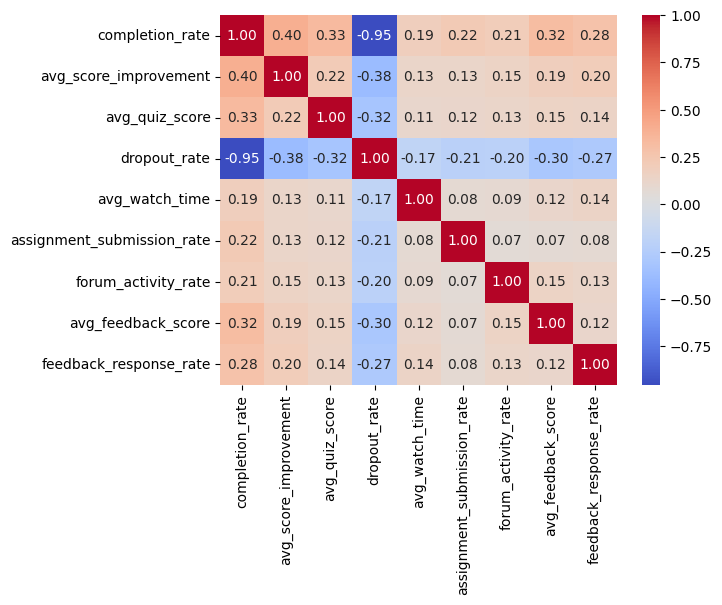

In [81]:
# Load the data

df = pd.read_csv("/content/instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv")

# collect information about the data
df.head()

df.info()

df.describe()

df.isnull().sum()

# (Convert to numpy array to chcek infinite values if exists)
# (we should select only numeric values)
# (will print column wise inf value if exists)

np.isinf(df.select_dtypes(include=["number"])).sum()

# check the correlation between values and heatmap
# (Select the values for correlation)
# issue faces(could not convert string to float: 'B_1861')

selected_colums = df.drop(columns=["batch_id","instructor_id","course_id"])
correlation = selected_colums.corr()
sns.heatmap(correlation,annot=True,cmap="coolwarm",fmt=".2f")
plt.show()

**Feature engineering**

1.How you calculated weights:

I looked at correlation of every features with completion_rate . i summed up all correlation values and divide each by total to get proportional weight maths i write below


2.Why completion_rate as proxy ?

i chose completion_rate as proxy because it directly reflects whether students stayed engaged with the instructor till the end of the course


3. Special Feature Decisions

dropout_rate = dropout_rate is a negative signal higher dropout means worse instructor by converting to 1 dropout_rate I created a positive retention signal so all features push in the same direction in the weighted formula

 avg_feedback_score =  avg_feedback_score is on a 1-5 scale while all other features are on 0-1 scale. Dividing by 5 brings it to 0-1 scale so it contributes proportionally — without this one feature would dominate unfairly due to scale difference

 weights based = weight based on correlation with completion_rate which may not perfectly represent effectiveness For example a course could have high completion rate because it was too easy — not because the instructor was excellent. Additional data like course difficulty rating would improve this definition


In [82]:
# We are creating new feature by analysing the correlations of columns with the completion_rate
# we have to add up all the data of 1 column and after sum that each value/sum to find the max weightage
# 1.00 + 0.40 + 0.33 + 0.95 + 0.19 + 0.22 + 0.21 + 0.32 + 0.28 = 3.90 aprox
# 3.90 / 9 ≈ 0.43
# Weights were derived by normalizing absolute correlations with completion rate
# assuming it represents instructor effectiveness

df["instructor_effectiveness"] = (
    0.26 * df["completion_rate"] +
    0.10 * df["avg_score_improvement"] +
    0.08 * df["avg_quiz_score"] +
    0.24 * (1-df["dropout_rate"]) +
    0.05 * df["avg_watch_time"] +
    0.06 * df["assignment_submission_rate"] +
    0.05 * df["forum_activity_rate"] +
    0.08 * (df["avg_feedback_score"]/5) +
    0.07 * df['feedback_response_rate']
)

Aggregation

In [83]:

inst_counts = df["instructor_id"].value_counts()
valid_ids = inst_counts[inst_counts >= 2].index
df = df[df["instructor_id"].isin(valid_ids)]

# we have to aggregate the values to a single row on the basis of instructor id
instructor_df = df.groupby(["instructor_id"]).agg({
    "completion_rate" : "mean",
    "avg_score_improvement" : "mean",
    "avg_quiz_score" : "mean" ,
    "dropout_rate" : "mean" ,
    "avg_watch_time" : "mean",
    "assignment_submission_rate" : "mean",
    "forum_activity_rate" : "mean",
    "avg_feedback_score" : "mean",
    "feedback_response_rate" : "mean",
    "instructor_effectiveness" :"mean"
}).reset_index()

# for label y we have to create "low","high","medium"
instructor_df["effectiveness_tier"]= pd.qcut(instructor_df["instructor_effectiveness"],q=3,labels=["Low","Medium","High"])

**Train test Split and Model Selection**

Accuracy:  0.8333333333333334
Classification report:                precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       0.67      0.80      0.73         5
      Medium       0.82      0.82      0.82        11

    accuracy                           0.83        24
   macro avg       0.83      0.83      0.83        24
weighted avg       0.85      0.83      0.84        24

confusion_matrix:  [[7 0 1]
 [0 4 1]
 [0 2 9]]


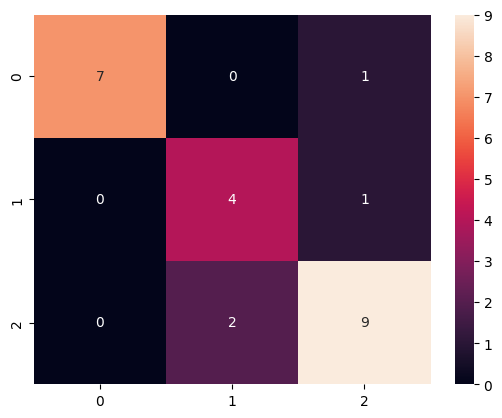

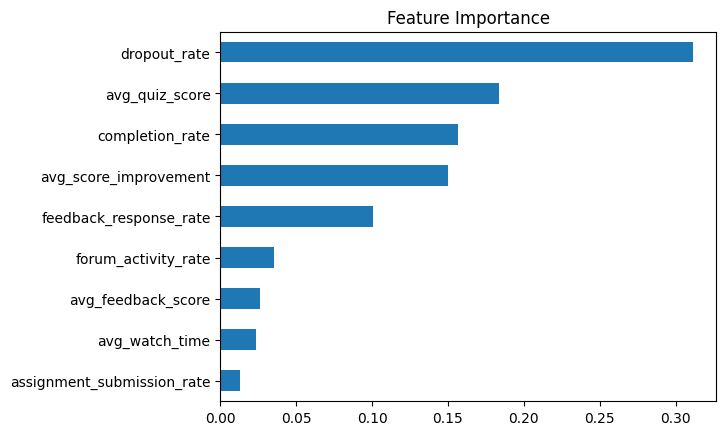

In [86]:
# Selection of Features
X = instructor_df.drop(columns=["instructor_id","effectiveness_tier","instructor_effectiveness"])
Y = instructor_df["effectiveness_tier"]

# Train test Split (dividing the portion for test and train where 80% for train and 20% for test)
x_train,x_test,y_train,y_test =  train_test_split(X,Y,test_size=0.2,random_state=42)

# Select the Model
model = RandomForestClassifier()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

# Accuracy
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Classification report: ",classification_report(y_test,y_pred))
conf_matrix =  confusion_matrix(y_test,y_pred)
print("confusion_matrix: ", confusion_matrix(y_test,y_pred))

#Heatmap
sns.heatmap(conf_matrix,annot=True)
plt.show()
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()



**Which features most influenced instructor effectiveness?**

1 . Drop_out make more impact beacuse it define whats wromg with the student why they are leaving the course is there any problem in course or educator


**Misleading variables ?**

2.completion_rate can be high because course was easy not because instructor was good avg_quiz_score can be high because students were motivated not instructor  credit dropout_rate can be low because course was mandatory so students had no choice

**How model can fail ?**

3.Model label is self defined by me if my weights are wrong, tiers are wrong model learns wrong patterns. Also small batch instructors have less data so predictions are unreliable"

**Additional data needed?**

4.Course difficulty rating, instructor experience in years batch size student prior knowledge level

**Should it be used for evaluation?**

5.Yes for identifying weak instructor  and coaching no for firing or penalizing model is based on self defined labels which may not be perfectly accurate

